In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
from pathlib import Path
import pandas as pd

INPUT_ROOT = Path("/kaggle/input")


def find_file(filename):
    matches = list(INPUT_ROOT.rglob(filename))

    if not matches:
        raise FileNotFoundError(f"{filename} not found")

    return matches[0]


TRAIN_CSV = find_file("train_split.csv")
VAL_CSV = find_file("internal_validation_split.csv")
TEST_CSV = find_file("test_split.csv")

print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VAL_CSV)
print("Test CSV:", TEST_CSV)

Train CSV: /kaggle/input/datasets/boshramahbub/malvies-for-efficientnet/train_split.csv
Validation CSV: /kaggle/input/datasets/boshramahbub/malvies-for-efficientnet/internal_validation_split.csv
Test CSV: /kaggle/input/datasets/boshramahbub/malvies-for-efficientnet/test_split.csv


In [11]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training images:", len(train_df))
print("Internal validation images:", len(val_df))
print("Final test images:", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())

display(train_df.head())

Training images: 6999
Internal validation images: 1751
Final test images: 3477

Columns:
['filepath', 'relative_path', 'class_name', 'label', 'label_id', 'hash']


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/490414f8e646fbad11d392106f38ec9...,Adposhel,Adposhel,0,5eabfcd800292738bcb70f818a8b9319
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/96022ca14d5b070258c892ebf7153e0...,Adposhel,Adposhel,0,55951eca5fdd3aa764b096cba7e06ab9
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/95c6546ecaf79394a4ace0512a52057...,Adposhel,Adposhel,0,bc1bd6f2cd6125334409930bba59d7a3
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/774964c435f7b10f3227fceebfad605...,Adposhel,Adposhel,0,66ad26b2bd35d5017c54210bcc0e03e1
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/91a0467c07dbb3282e07dc0a214846a...,Adposhel,Adposhel,0,c7baaebfdcf4ca3c1561105727feefb1


In [12]:
image_files = (
    list(INPUT_ROOT.rglob("*.png"))
    + list(INPUT_ROOT.rglob("*.jpg"))
    + list(INPUT_ROOT.rglob("*.jpeg"))
)

print("Total original images found:", len(image_files))

if image_files:
    print("Example image:", image_files[0])
else:
    print("Original MaleVis images are not attached yet.")

Total original images found: 14226
Example image: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/b653a24164f3a05bfe126bf84eac87390634b6e7resized_image.png


In [13]:
# Show the available columns
print("Train columns:", train_df.columns.tolist())

# Automatically identify important columns
PATH_COL = next(
    col for col in ["filepath", "file_path", "path", "relative_path"]
    if col in train_df.columns
)

LABEL_COL = next(
    col for col in ["class_name", "label", "class"]
    if col in train_df.columns
)

print("Path column:", PATH_COL)
print("Label column:", LABEL_COL)

Train columns: ['filepath', 'relative_path', 'class_name', 'label', 'label_id', 'hash']
Path column: filepath
Label column: class_name


In [14]:
from pathlib import Path

for split_name, dataframe in {
    "Train": train_df,
    "Internal Validation": val_df,
    "Test": test_df
}.items():

    missing_files = dataframe[PATH_COL].apply(
        lambda path: not Path(str(path)).exists()
    ).sum()

    print(f"\n{split_name}")
    print("Images:", len(dataframe))
    print("Classes:", dataframe[LABEL_COL].nunique())
    print("Missing files:", missing_files)
    print(
        "Contains Other:",
        dataframe[LABEL_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("other")
        .any()
    )


Train
Images: 6999
Classes: 25
Missing files: 0
Contains Other: False

Internal Validation
Images: 1751
Classes: 25
Missing files: 0
Contains Other: False

Test
Images: 3477
Classes: 25
Missing files: 0
Contains Other: False


# Configuration and augmentation

In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.02,
            seed=SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.02,
            width_factor=0.02,
            seed=SEED
        ),
    ],
    name="efficientnet_augmentation"
)

# Image-loading function

In [26]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)

    return image, label

In [27]:
def create_efficientnet_dataset(
    dataframe,
    training=False
):
    filepaths = dataframe["filepath"].astype(str).values
    labels = dataframe["label_id"].astype(np.int32).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    if training:
        dataset = dataset.map(
            lambda images, labels: (
                data_augmentation(
                    images,
                    training=True
                ),
                labels
            ),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [28]:
efficientnet_train_ds = create_efficientnet_dataset(
    train_df,
    training=True
)

efficientnet_val_ds = create_efficientnet_dataset(
    val_df,
    training=False
)

efficientnet_test_ds = create_efficientnet_dataset(
    test_df,
    training=False
)

print("EfficientNet datasets created successfully.")

EfficientNet datasets created successfully.


In [29]:
train_images, train_labels = next(
    iter(efficientnet_train_ds)
)

print("Image batch shape:", train_images.shape)
print("Label batch shape:", train_labels.shape)

print("Image dtype:", train_images.dtype)
print("Label dtype:", train_labels.dtype)

print("Minimum pixel value:",
      float(tf.reduce_min(train_images)))

print("Maximum pixel value:",
      float(tf.reduce_max(train_images)))

print("Minimum label:",
      int(tf.reduce_min(train_labels)))

print("Maximum label:",
      int(tf.reduce_max(train_labels)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Minimum pixel value: 0.0
Maximum pixel value: 254.9995880126953
Minimum label: 1
Maximum label: 22


In [30]:
print("Train label range:",
      train_df["label_id"].min(),
      "to",
      train_df["label_id"].max())

print("Validation label range:",
      val_df["label_id"].min(),
      "to",
      val_df["label_id"].max())

print("Test label range:",
      test_df["label_id"].min(),
      "to",
      test_df["label_id"].max())

Train label range: 0 to 24
Validation label range: 0 to 24
Test label range: 0 to 24


# build the frozen EfficientNet-B0 model

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SHAPE = (224, 224, 3)
NUM_CLASSES = 25

efficientnet_base = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SHAPE
)

# Stage 1: freeze the complete ImageNet backbone
efficientnet_base.trainable = False

inputs = layers.Input(
    shape=IMG_SHAPE,
    name="input_image"
)

# EfficientNet receives images in the 0–255 range
x = efficientnet_base(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="class_predictions"
)(x)

efficientnet_b0_model = Model(
    inputs,
    outputs,
    name="MaleVis_EfficientNetB0"
)

efficientnet_b0_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

efficientnet_b0_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MaleVis_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_predictions (Dense)       │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081,596 (15.57 MB)

 Trainable params: 32,025 (125.10 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Train the frozen model

In [35]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

OUTPUT_DIR = Path("/kaggle/working/efficientnet_b0_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_MODEL_PATH = OUTPUT_DIR / "efficientnet_b0_frozen_best.keras"

**Calculating class weight**

In [36]:
train_labels_array = train_df["label_id"].astype(int).values
class_ids = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_labels_array
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}

print("Class weights:")
for class_id, weight in class_weights.items():
    print(f"Class {class_id:2d}: {weight:.4f}")

Class weights:
Class  0: 0.9999
Class  1: 0.9999
Class  2: 0.9999
Class  3: 0.9963
Class  4: 0.9999
Class  5: 0.9999
Class  6: 0.9999
Class  7: 0.9999
Class  8: 0.9999
Class  9: 0.9999
Class 10: 1.0071
Class 11: 0.9999
Class 12: 0.9999
Class 13: 0.9999
Class 14: 0.9999
Class 15: 0.9999
Class 16: 0.9999
Class 17: 0.9999
Class 18: 0.9999
Class 19: 0.9999
Class 20: 0.9999
Class 21: 0.9999
Class 22: 0.9999
Class 23: 0.9999
Class 24: 0.9999


**Create callbacks**

In [37]:
stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

**Train the frozen backbone**

In [38]:
stage1_start_time = time.time()

efficientnet_stage1_history = efficientnet_b0_model.fit(
    efficientnet_train_ds,
    validation_data=efficientnet_val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)

stage1_training_time = time.time() - stage1_start_time

print(
    f"\nStage 1 training time: "
    f"{stage1_training_time / 60:.2f} minutes"
)

print("Best frozen model saved at:")
print(STAGE1_MODEL_PATH)

Epoch 1/20


2026-07-27 18:33:27.947871: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:33:28.091291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:33:28.450102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:33:28.591314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:33:29.393696: E external/local_xla/xla/stream_

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.4372 - loss: 2.2465

2026-07-27 18:34:34.761520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:34:34.903628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:34:35.249509: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:34:35.390598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-27 18:34:36.208205: E external/local_xla/xla/stream_

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.4380 - loss: 2.2436
Epoch 1: val_loss improved from None to 1.19713, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 114s 396ms/step - accuracy: 0.6112 - loss: 1.6299 - val_accuracy: 0.7019 - val_loss: 1.1971 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7701 - loss: 0.9579
Epoch 2: val_loss improved from 1.19713 to 0.97739, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_frozen_best.keras

Epoch 2: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 195ms/step - accuracy: 0.7858 - loss: 0.9015 - val_accuracy: 0.7527 - val_loss: 0.9774 - learning_rate: 0.0010
Epoch 3/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 181m

In [39]:
best_stage1_epoch = (
    np.argmin(efficientnet_stage1_history.history["val_loss"]) + 1
)

best_stage1_val_loss = min(
    efficientnet_stage1_history.history["val_loss"]
)

best_stage1_val_accuracy = max(
    efficientnet_stage1_history.history["val_accuracy"]
)

print("Best Stage 1 epoch:", best_stage1_epoch)
print(f"Best validation loss: {best_stage1_val_loss:.4f}")
print(f"Best validation accuracy: {best_stage1_val_accuracy:.4f}")

Best Stage 1 epoch: 20
Best validation loss: 0.6727
Best validation accuracy: 0.8235


In [40]:
import tensorflow as tf
import time
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/efficientnet_b0_outputs")

STAGE1_MODEL_PATH = (
    OUTPUT_DIR / "efficientnet_b0_frozen_best.keras"
)

STAGE2_MODEL_PATH = (
    OUTPUT_DIR / "efficientnet_b0_finetuned_best.keras"
)

efficientnet_finetune_model = tf.keras.models.load_model(
    STAGE1_MODEL_PATH
)

efficientnet_base = (
    efficientnet_finetune_model.get_layer("efficientnetb0")
)

print("Best frozen model loaded.")

Best frozen model loaded.


In [41]:
efficientnet_base.trainable = True

# Freeze the entire backbone first
for layer in efficientnet_base.layers:
    layer.trainable = False

# Unfreeze only the last 30 layers,
# while keeping Batch Normalization frozen
for layer in efficientnet_base.layers[-30:]:
    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = True

In [42]:
trainable_backbone_layers = [
    layer.name
    for layer in efficientnet_base.layers
    if layer.trainable
]

print(
    "Trainable EfficientNet backbone layers:",
    len(trainable_backbone_layers)
)

print("\nTrainable layer names:")
for layer_name in trainable_backbone_layers:
    print(layer_name)

Trainable EfficientNet backbone layers: 23

Trainable layer names:
block6d_expand_activation
block6d_dwconv
block6d_activation
block6d_se_squeeze
block6d_se_reshape
block6d_se_reduce
block6d_se_expand
block6d_se_excite
block6d_project_conv
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_activation
block7a_dwconv
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
top_conv
top_activation


In [43]:
efficientnet_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)
efficientnet_finetune_model.summary()

Model: "MaleVis_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_predictions (Dense)       │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081,596 (15.57 MB)

 Trainable params: 1,515,385 (5.78 MB)

 Non-trainable params: 2,566,211 (9.79 MB)

# Fine-tuning callbacks

In [44]:
stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE2_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

**Run fine-tuning**

In [45]:
stage2_start_time = time.time()

efficientnet_stage2_history = (
    efficientnet_finetune_model.fit(
        efficientnet_train_ds,
        validation_data=efficientnet_val_ds,
        initial_epoch=20,
        epochs=30,
        class_weight=class_weights,
        callbacks=stage2_callbacks,
        verbose=1
    )
)

stage2_training_time = (
    time.time() - stage2_start_time
)

print(
    f"\nStage 2 training time: "
    f"{stage2_training_time / 60:.2f} minutes"
)

Epoch 21/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8886 - loss: 0.4107
Epoch 21: val_loss improved from None to 0.68566, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras

Epoch 21: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 92s 305ms/step - accuracy: 0.8876 - loss: 0.4076 - val_accuracy: 0.8075 - val_loss: 0.6857 - learning_rate: 1.0000e-05
Epoch 22/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8907 - loss: 0.4002
Epoch 22: val_loss improved from 0.68566 to 0.64081, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras

Epoch 22: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 44s 197ms/step - accuracy: 0.8891 - loss: 0.3963 - val_accuracy: 0.8258 - val_loss: 0.6408 - learning_rate: 1.0000e-05
Epoch 23/30

In [46]:
stage2_val_losses = (
    efficientnet_stage2_history.history["val_loss"]
)

stage2_val_accuracies = (
    efficientnet_stage2_history.history["val_accuracy"]
)

best_stage2_index = int(
    np.argmin(stage2_val_losses)
)

best_stage2_epoch = 21 + best_stage2_index

best_stage2_val_loss = min(
    stage2_val_losses
)

best_stage2_val_accuracy = max(
    stage2_val_accuracies
)

print(
    "Best Stage 2 epoch:",
    best_stage2_epoch
)

print(
    f"Best fine-tuning validation loss: "
    f"{best_stage2_val_loss:.4f}"
)

print(
    f"Best fine-tuning validation accuracy: "
    f"{best_stage2_val_accuracy:.4f}"
)

Best Stage 2 epoch: 30
Best fine-tuning validation loss: 0.5728
Best fine-tuning validation accuracy: 0.8458


**extra 5 more**

In [47]:
# Load the current best fine-tuned checkpoint
efficientnet_finetune_model = tf.keras.models.load_model(
    STAGE2_MODEL_PATH
)

# Use an even smaller learning rate
efficientnet_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-6
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

stage2_extension_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE2_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

extension_history = efficientnet_finetune_model.fit(
    efficientnet_train_ds,
    validation_data=efficientnet_val_ds,
    initial_epoch=30,
    epochs=35,
    class_weight=class_weights,
    callbacks=stage2_extension_callbacks,
    verbose=1
)

Epoch 31/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9135 - loss: 0.3072
Epoch 31: val_loss improved from None to 0.57132, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras

Epoch 31: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 89s 296ms/step - accuracy: 0.9123 - loss: 0.3096 - val_accuracy: 0.8464 - val_loss: 0.5713 - learning_rate: 2.0000e-06
Epoch 32/35
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9262 - loss: 0.2789
Epoch 32: val_loss improved from 0.57132 to 0.57041, saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras

Epoch 32: finished saving model to /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 193ms/step - accuracy: 0.9183 - loss: 0.2960 - val_accuracy: 0.8452 - val_loss: 0.5704 - learning_rate: 2.0000e-06
Epoch 33/35

In [49]:
extension_val_losses = extension_history.history["val_loss"]
extension_val_accuracies = extension_history.history["val_accuracy"]

best_extension_index = int(np.argmin(extension_val_losses))
best_extension_epoch = 31 + best_extension_index

print("Best extension epoch:", best_extension_epoch)
print(
    "Best extension validation loss:",
    round(min(extension_val_losses), 4)
)
print(
    "Best extension validation accuracy:",
    round(max(extension_val_accuracies), 4)
)

Best extension epoch: 34
Best extension validation loss: 0.5559
Best extension validation accuracy: 0.8487


In [52]:
final_efficientnet_model = tf.keras.models.load_model(
    STAGE2_MODEL_PATH
)

efficientnet_test_loss, efficientnet_test_accuracy = (
    final_efficientnet_model.evaluate(
        efficientnet_test_ds,
        verbose=1
    )
)

print("\nSelected model: Fine-tuned EfficientNet-B0")
print(f"Final test loss: {efficientnet_test_loss:.4f}")
print(
    f"Final test accuracy: "
    f"{efficientnet_test_accuracy:.4f}"
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8568 - loss: 0.5249

Selected model: Fine-tuned EfficientNet-B0
Final test loss: 0.5249
Final test accuracy: 0.8568


In [53]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import label_binarize

# Generate probabilities and predictions
efficientnet_probabilities = final_efficientnet_model.predict(
    efficientnet_test_ds,
    verbose=1
)

efficientnet_predictions = np.argmax(
    efficientnet_probabilities,
    axis=1
)

efficientnet_true_labels = np.concatenate(
    [
        labels.numpy()
        for images, labels in efficientnet_test_ds
    ]
)

# Class names in label-ID order
class_mapping = (
    train_df[["class_name", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
)

class_names = class_mapping["class_name"].tolist()
class_ids = np.arange(NUM_CLASSES)

# Confusion matrix
cm = confusion_matrix(
    efficientnet_true_labels,
    efficientnet_predictions,
    labels=class_ids
)

# Multiclass specificity: one-vs-rest
specificities = []

for class_id in class_ids:
    tp = cm[class_id, class_id]
    fn = cm[class_id, :].sum() - tp
    fp = cm[:, class_id].sum() - tp
    tn = cm.sum() - tp - fn - fp

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    specificities.append(specificity)

class_support = cm.sum(axis=1)

macro_specificity = float(np.mean(specificities))

weighted_specificity = float(
    np.average(
        specificities,
        weights=class_support
    )
)

# One-hot labels for ROC-AUC and PR-AUC
true_labels_binary = label_binarize(
    efficientnet_true_labels,
    classes=class_ids
)

metrics = {
    "Model": "Fine-tuned EfficientNet-B0",

    "Accuracy": accuracy_score(
        efficientnet_true_labels,
        efficientnet_predictions
    ),

    "Macro Precision": precision_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro Specificity": macro_specificity,

    "Macro F1": f1_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="macro",
        zero_division=0
    ),

    "Weighted Precision": precision_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="weighted",
        zero_division=0
    ),

    "Weighted Recall": recall_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="weighted",
        zero_division=0
    ),

    "Weighted Specificity": weighted_specificity,

    "Weighted F1": f1_score(
        efficientnet_true_labels,
        efficientnet_predictions,
        average="weighted",
        zero_division=0
    ),

    "Macro ROC-AUC": roc_auc_score(
        true_labels_binary,
        efficientnet_probabilities,
        average="macro",
        multi_class="ovr"
    ),

    "Weighted ROC-AUC": roc_auc_score(
        true_labels_binary,
        efficientnet_probabilities,
        average="weighted",
        multi_class="ovr"
    ),

    "Macro PR-AUC": average_precision_score(
        true_labels_binary,
        efficientnet_probabilities,
        average="macro"
    ),

    "Weighted PR-AUC": average_precision_score(
        true_labels_binary,
        efficientnet_probabilities,
        average="weighted"
    ),

    "Log Loss": log_loss(
        efficientnet_true_labels,
        efficientnet_probabilities,
        labels=class_ids
    )
}

efficientnet_metrics_df = pd.DataFrame([metrics])

display(
    efficientnet_metrics_df.T.rename(
        columns={0: "Value"}
    )
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step


,Value
Model,Fine-tuned EfficientNet-B0
Accuracy,0.856773
Macro Precision,0.875769
Macro Recall,0.861844
Macro Specificity,0.994036
Macro F1,0.861784
Weighted Precision,0.875571
Weighted Recall,0.856773
Weighted Specificity,0.994121
Weighted F1,0.859293


In [54]:
efficientnet_classification_report = classification_report(
    efficientnet_true_labels,
    efficientnet_predictions,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(efficientnet_classification_report)

              precision    recall  f1-score   support

    Adposhel     0.9930    0.9861    0.9895       144
       Agent     0.3794    0.8000    0.5147       120
     Allaple     0.8750    0.9297    0.9015       128
   Amonetize     0.8673    0.8763    0.8718        97
      Androm     0.8659    0.9467    0.9045       150
     Autorun     0.6528    0.8630    0.7434       146
   BrowseFox     0.9630    0.9091    0.9353       143
      Dinwod     0.9737    0.7450    0.8441       149
        Elex     0.8000    0.9600    0.8727       150
      Expiro     0.8211    0.6689    0.7372       151
      Fasong     1.0000    1.0000    1.0000        33
     HackKMS     0.9597    0.9597    0.9597       149
        Hlux     0.9868    0.9933    0.9900       150
    Injector     0.8195    0.7517    0.7842       145
 InstallCore     0.9932    0.9733    0.9832       150
   MultiPlug     0.9538    0.8322    0.8889       149
  Neoreklami     0.9865    0.9733    0.9799       150
      Neshta     0.5487    

In [55]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd

OUTPUT_DIR = Path("/kaggle/working/efficientnet_b0_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# 1. Save the final selected model
# -------------------------------------------------
FINAL_MODEL_PATH = OUTPUT_DIR / "efficientnet_b0_final.keras"

final_efficientnet_model.save(FINAL_MODEL_PATH)

print("Final model saved:", FINAL_MODEL_PATH)


# -------------------------------------------------
# 2. Save complete metric table
# -------------------------------------------------
efficientnet_metrics_df.to_csv(
    OUTPUT_DIR / "efficientnet_b0_metrics.csv",
    index=False
)


# -------------------------------------------------
# 3. Save classification report
# -------------------------------------------------
with open(
    OUTPUT_DIR / "efficientnet_b0_classification_report.txt",
    "w"
) as file:
    file.write(efficientnet_classification_report)


# -------------------------------------------------
# 4. Save confusion matrix values
# -------------------------------------------------
confusion_matrix_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

confusion_matrix_df.to_csv(
    OUTPUT_DIR / "efficientnet_b0_confusion_matrix.csv"
)


# -------------------------------------------------
# 5. Save class-name mapping
# -------------------------------------------------
class_mapping.to_csv(
    OUTPUT_DIR / "class_mapping.csv",
    index=False
)


# -------------------------------------------------
# 6. Save model summary
# -------------------------------------------------
summary_lines = []

final_efficientnet_model.summary(
    print_fn=lambda line: summary_lines.append(line)
)

with open(
    OUTPUT_DIR / "efficientnet_b0_model_summary.txt",
    "w"
) as file:
    file.write("\n".join(summary_lines))


# -------------------------------------------------
# 7. Calculate parameter count and model size
# -------------------------------------------------
total_parameters = final_efficientnet_model.count_params()

trainable_parameters = int(
    sum(
        np.prod(weight.shape)
        for weight in final_efficientnet_model.trainable_weights
    )
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)

model_size_mb = os.path.getsize(
    FINAL_MODEL_PATH
) / (1024 ** 2)


# -------------------------------------------------
# 8. Save final experiment summary
# -------------------------------------------------
experiment_summary = pd.DataFrame([{
    "Model": "Fine-tuned EfficientNet-B0",
    "Training Images": 6999,
    "Internal Validation Images": 1751,
    "Test Images": 3477,
    "Number of Classes": 25,
    "Image Size": "224x224x3",
    "Batch Size": 32,
    "Frozen Validation Accuracy": 0.8235,
    "Frozen Validation Loss": 0.6727,
    "Selected Validation Accuracy": 0.8487,
    "Selected Validation Loss": 0.5559,
    "Selected Epoch": 34,
    "Final Test Accuracy": 0.8568,
    "Final Test Loss": 0.5249,
    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Non-trainable Parameters": non_trainable_parameters,
    "Saved Model Size MB": model_size_mb
}])

experiment_summary.to_csv(
    OUTPUT_DIR / "efficientnet_b0_experiment_summary.csv",
    index=False
)

display(experiment_summary)

Final model saved: /kaggle/working/efficientnet_b0_outputs/efficientnet_b0_final.keras


,Model,Training Images,Internal Validation Images,Test Images,Number of Classes,Image Size,Batch Size,Frozen Validation Accuracy,Frozen Validation Loss,Selected Validation Accuracy,Selected Validation Loss,Selected Epoch,Final Test Accuracy,Final Test Loss,Total Parameters,Trainable Parameters,Non-trainable Parameters,Saved Model Size MB
0,Fine-tuned EfficientNet-B0,6999,1751,3477,25,224x224x3,32,0.8235,0.6727,0.8487,0.5559,34,0.8568,0.5249,4081596,1515385,2566211,27.940073


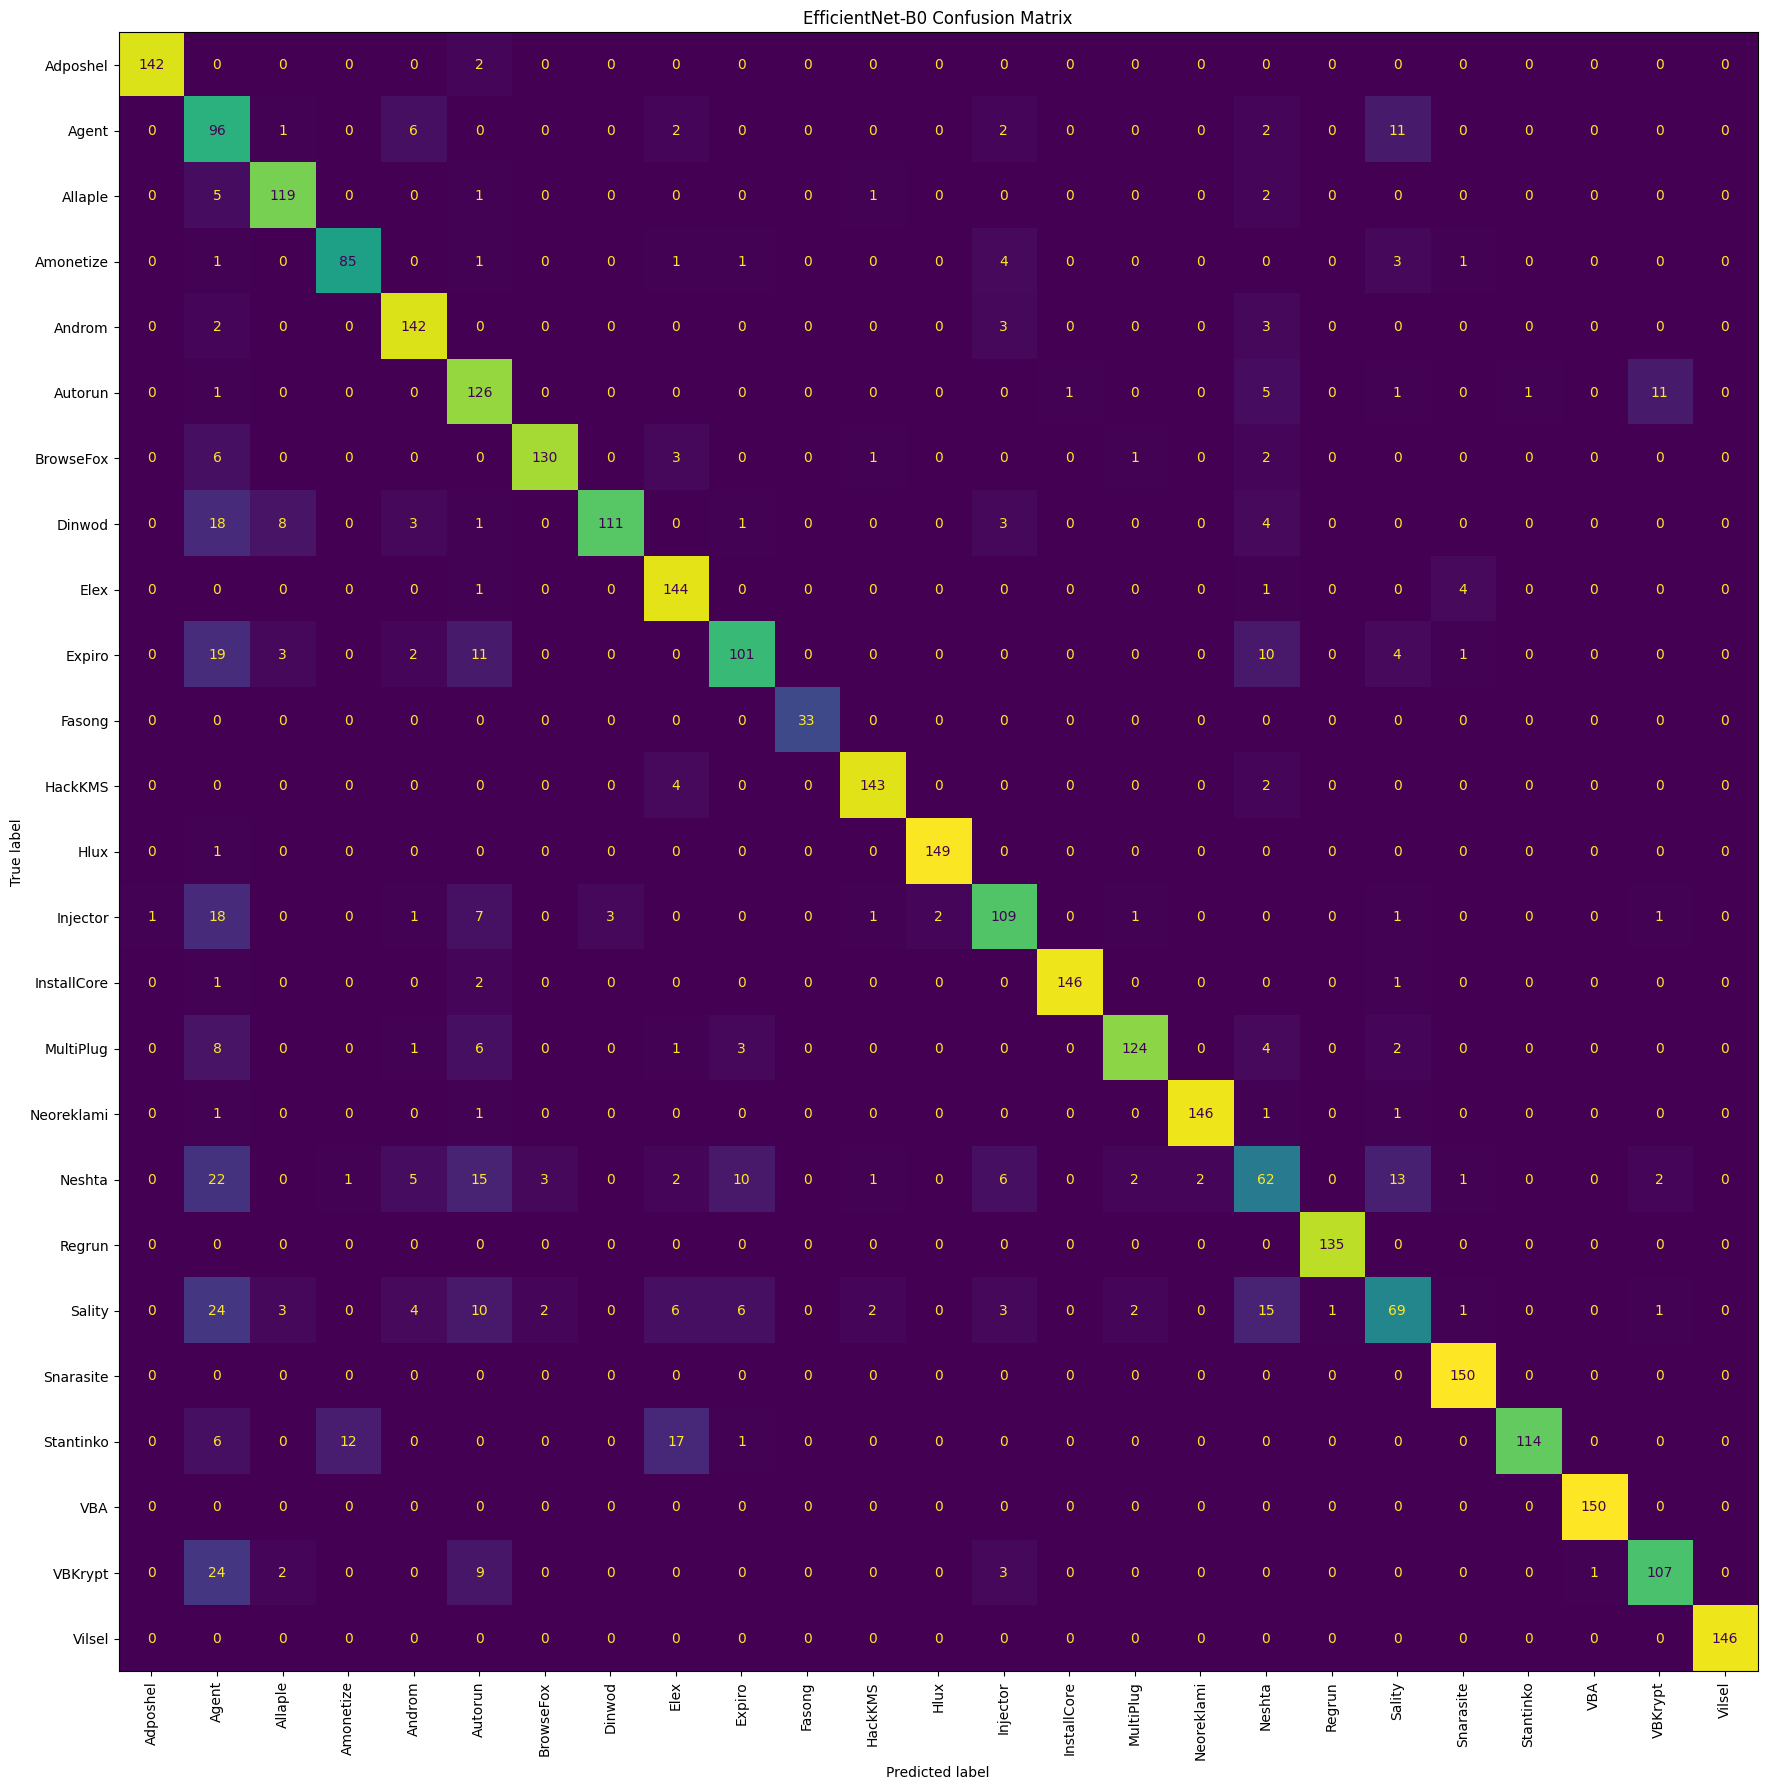

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(18, 18))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display_cm.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

plt.title("EfficientNet-B0 Confusion Matrix")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "efficientnet_b0_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Combine the three training stages
stage1_df = pd.DataFrame(
    efficientnet_stage1_history.history
)
stage1_df["Epoch"] = np.arange(1, len(stage1_df) + 1)
stage1_df["Stage"] = "Frozen"

stage2_df = pd.DataFrame(
    efficientnet_stage2_history.history
)
stage2_df["Epoch"] = np.arange(
    21,
    21 + len(stage2_df)
)
stage2_df["Stage"] = "Fine-tuning"

extension_df = pd.DataFrame(
    extension_history.history
)
extension_df["Epoch"] = np.arange(
    31,
    31 + len(extension_df)
)
extension_df["Stage"] = "Extension"

complete_history_df = pd.concat(
    [stage1_df, stage2_df, extension_df],
    ignore_index=True
)

complete_history_df.to_csv(
    OUTPUT_DIR / "efficientnet_b0_training_history.csv",
    index=False
)

display(complete_history_df.tail())

,accuracy,loss,val_accuracy,val_loss,learning_rate,Epoch,Stage
30,0.912273,0.309621,0.846373,0.571318,0.000002,31,Extension
31,0.918274,0.295961,0.845231,0.570409,0.000002,32,Extension
32,0.915131,0.303661,0.848087,0.563344,0.000002,33,Extension
33,0.911416,0.304740,0.848658,0.555899,0.000002,34,Extension
34,0.911559,0.304573,0.846945,0.557256,0.000002,35,Extension


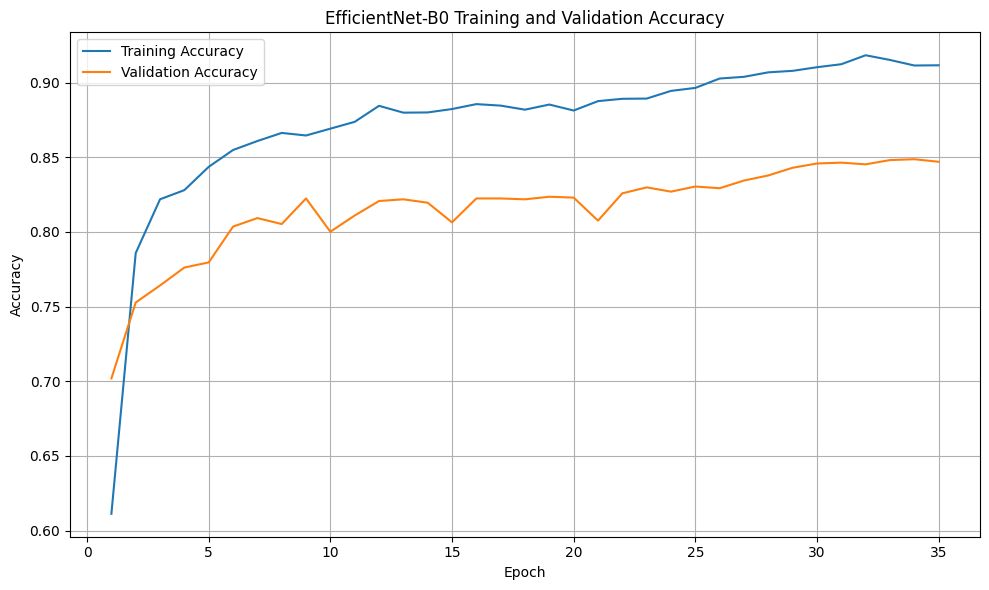

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "efficientnet_b0_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

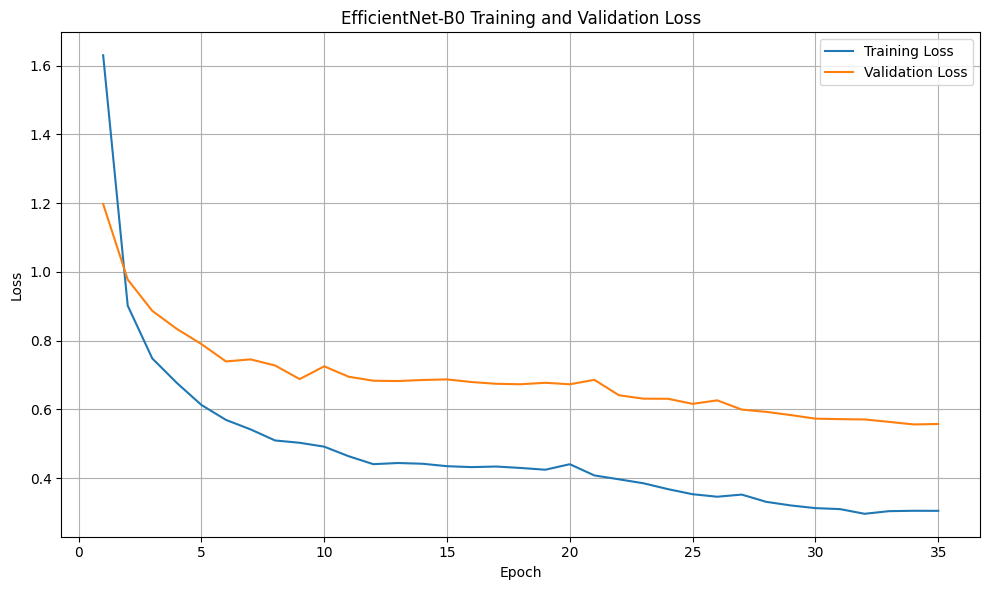

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "efficientnet_b0_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
ZIP_PATH = shutil.make_archive(
    "/kaggle/working/efficientnet_b0_complete_results",
    "zip",
    OUTPUT_DIR
)

print("ZIP created successfully:")
print(ZIP_PATH)

ZIP created successfully:
/kaggle/working/efficientnet_b0_complete_results.zip
